In [1]:
# ============================================================================
# COMPLETE NEURAL NETWORK TRAINING WALKTHROUGH
# ----------------------------------------------------------------------------
# Pipeline:
#   1. Generate synthetic dataset (NumPy)
#   2. Split into train/val/test
#   3. Wrap in PyTorch Dataset
#   4. Create DataLoaders
#   5. Define neural network model
#   6. Set up loss + optimizer + LR scheduler
#   7. Training loop with detailed shape tracking
#   8. Evaluation
#   9. Save model (state_dict + full model + TorchScript)
#  10. Load and serve predictions
# ============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# Reproducibility — this is non-negotiable for any serious experiment.
# Setting seeds across numpy, torch CPU, and torch CUDA so that runs are deterministic.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device selection — use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ============================================================================
# STEP 1: GENERATE SYNTHETIC DATASET
# ----------------------------------------------------------------------------
# Problem setup: We're building a 3-class classifier on 10-dimensional inputs.
# The decision boundary will be nonlinear so the network actually has to learn
# something — a linear model would not solve this.
# ============================================================================

N_SAMPLES = 5000   # total dataset size
N_FEATURES = 10    # input dimensionality
N_CLASSES = 3      # number of output classes

def generate_synthetic_data(n_samples, n_features, n_classes):
    """
    Generate a synthetic classification dataset with a nonlinear decision boundary.
    
    Strategy: 
      - Sample features from a standard normal distribution
      - Create labels based on a nonlinear function of the features 
        (sum of pairwise products of first 4 features, plus some noise)
      - This guarantees the problem is NOT linearly separable
    """
    # X shape: (n_samples, n_features). Each row is one sample, each column one feature.
    X = np.random.randn(n_samples, n_features).astype(np.float32)
    
    # Build a nonlinear "true function" to generate labels
    # This is a quadratic form — products of features cross feature boundaries
    # This is the kind of relationship a linear model can't capture but a neural net can
    nonlinear_signal = (
        X[:, 0] * X[:, 1]              # product of features 0 and 1
        + X[:, 2] ** 2                  # squared feature 2
        - X[:, 3] * X[:, 4]             # negative product
        + 0.3 * np.random.randn(n_samples)   # noise — makes the task harder, more realistic
    )
    # nonlinear_signal shape: (n_samples,)  — just a 1D array of "scores"
    
    # Convert scores to class labels using percentile thresholds
    # This guarantees roughly balanced classes (each class gets ~33% of samples)
    thresholds = np.percentile(nonlinear_signal, [33.33, 66.67])
    y = np.zeros(n_samples, dtype=np.int64)
    y[nonlinear_signal > thresholds[0]] = 1
    y[nonlinear_signal > thresholds[1]] = 2
    # y shape: (n_samples,) — integer class labels in {0, 1, 2}
    
    return X, y

X_all, y_all = generate_synthetic_data(N_SAMPLES, N_FEATURES, N_CLASSES)

print(f"X_all shape: {X_all.shape}, dtype: {X_all.dtype}")
# Output: X_all shape: (5000, 10), dtype: float32
print(f"y_all shape: {y_all.shape}, dtype: {y_all.dtype}")
# Output: y_all shape: (5000,), dtype: int64
print(f"Class distribution: {np.bincount(y_all)}")
# Output: roughly [1667, 1666, 1667] — balanced

# IMPORTANT dtype notes:
#   - Features must be float32 (PyTorch's default tensor dtype for compute)
#     Using float64 wastes memory and is slower on GPUs
#   - Labels must be int64 (a.k.a. long) — this is what nn.CrossEntropyLoss expects
#     Using int32 will throw a runtime error

X_all shape: (5000, 10), dtype: float32
y_all shape: (5000,), dtype: int64
Class distribution: [1667 1666 1667]


In [3]:
# ============================================================================
# STEP 2: NORMALIZE FEATURES
# ----------------------------------------------------------------------------
# Neural networks are extremely sensitive to input scale (unlike trees).
# Best practice: standardize to zero mean, unit variance per feature.
#
# CRITICAL: Compute normalization statistics ONLY from training data.
# Then apply those same statistics to val/test. Computing stats on the full 
# dataset is "data leakage" — your test set indirectly informs preprocessing.
# ============================================================================

# We'll do the split first, then normalize, to avoid leakage.
# Split sizes: 70% train, 15% val, 15% test
n_train = int(0.70 * N_SAMPLES)
n_val   = int(0.15 * N_SAMPLES)
n_test  = N_SAMPLES - n_train - n_val   # 15%, handles remainder

# Shuffle indices once — never shuffle X and y separately, you'd misalign them
indices = np.random.permutation(N_SAMPLES)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

print(f"Train: X={X_train.shape}, y={y_train.shape}")  # (3500, 10), (3500,)
print(f"Val:   X={X_val.shape}, y={y_val.shape}")       # (750, 10), (750,)
print(f"Test:  X={X_test.shape}, y={y_test.shape}")     # (750, 10), (750,)

# Compute mean and std FROM TRAINING DATA ONLY
mean = X_train.mean(axis=0)   # shape: (n_features,) = (10,)
std  = X_train.std(axis=0)    # shape: (n_features,) = (10,)

# Apply to all splits using the training statistics
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Sanity check: training data should now have ~0 mean and ~1 std per feature
print(f"After normalization — train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")
# Should be approximately 0.0 and 1.0

Train: X=(3500, 10), y=(3500,)
Val:   X=(750, 10), y=(750,)
Test:  X=(750, 10), y=(750,)
After normalization — train mean: -0.0000, std: 1.0000


In [4]:
# ============================================================================
# STEP 3: PYTORCH DATASET CLASS
# ----------------------------------------------------------------------------
# A Dataset in PyTorch is just a class with three methods:
#   __init__: store the data
#   __len__:  return how many samples there are
#   __getitem__: return ONE sample by index
#
# That's it. The DataLoader handles batching, shuffling, multi-process loading.
# This separation is clean: Dataset = "how to get one sample", 
#                          DataLoader = "how to batch and feed samples".
# ============================================================================

class SyntheticDataset(Dataset):
    def __init__(self, X, y):
        """
        Convert numpy arrays to PyTorch tensors ONCE at init time.
        
        Why here and not in __getitem__?
          - Memory: tensors are stored contiguously, numpy too — no duplication
          - Speed: avoid converting on every __getitem__ call
          - Gradient tracking: these tensors won't carry gradients (data, not parameters)
        """
        # Convert features to float32 tensor
        # torch.from_numpy SHARES memory with the numpy array (no copy)
        # .float() ensures float32 dtype (PyTorch default for training)
        self.X = torch.from_numpy(X).float()
        # X shape: (n_samples, n_features) — same as numpy
        
        # Labels as long tensor (int64) — required by CrossEntropyLoss
        self.y = torch.from_numpy(y).long()
        # y shape: (n_samples,) — 1D tensor of class indices
        
        # IMPORTANT: requires_grad = False (default)
        # Data tensors should never carry gradients — they're not learnable parameters
        # The optimizer only updates things with requires_grad=True
    
    def __len__(self):
        """Return total number of samples. DataLoader calls this to know dataset size."""
        return len(self.X)
    
    def __getitem__(self, idx):
        """
        Return a single (features, label) pair.
        DataLoader will call this with different idx values, then stack the results.
        """
        # Returns:
        #   features: tensor of shape (n_features,) = (10,)
        #   label:    scalar tensor of shape ()
        return self.X[idx], self.y[idx]

# Instantiate datasets
train_dataset = SyntheticDataset(X_train, y_train)
val_dataset   = SyntheticDataset(X_val,   y_val)
test_dataset  = SyntheticDataset(X_test,  y_test)

# Test the dataset — get sample 0
sample_x, sample_y = train_dataset[0]
print(f"Single sample x shape: {sample_x.shape}, dtype: {sample_x.dtype}")
# Output: Single sample x shape: torch.Size([10]), dtype: torch.float32
print(f"Single sample y: {sample_y}, dtype: {sample_y.dtype}")
# Output: Single sample y: tensor(2), dtype: torch.int64
print(f"Sample x requires_grad: {sample_x.requires_grad}")
# Output: False — data tensors NEVER carry gradients

Single sample x shape: torch.Size([10]), dtype: torch.float32
Single sample y: 2, dtype: torch.int64
Sample x requires_grad: False


In [5]:
# ============================================================================
# STEP 4: DATALOADERS
# ----------------------------------------------------------------------------
# DataLoader handles:
#   - Batching:  stacks N samples into a batch of shape (N, *sample_shape)
#   - Shuffling: randomizes order each epoch (training only!)
#   - Parallelism: num_workers > 0 spawns subprocesses for parallel data loading
#   - Pin memory: speeds up CPU→GPU transfer (use when training on GPU)
# ============================================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,         # MUST shuffle training data each epoch — prevents
                          # the model from memorizing the data order
    num_workers=0,        # 0 = load in main process. For real workloads, set to
                          # ~number of CPU cores. Setting to 0 here to avoid
                          # multiprocessing issues in notebooks.
    pin_memory=(device.type == "cuda"),  # Speeds up GPU transfer
    drop_last=True        # Drop the last incomplete batch — keeps batch sizes
                          # consistent, helps BatchNorm and reproducibility
)

# IMPORTANT: never shuffle val/test loaders. You want consistent ordering
# so metrics are comparable across runs.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

# Inspect a batch
for batch_x, batch_y in train_loader:
    print(f"Batch x shape: {batch_x.shape}")  
    # Output: torch.Size([64, 10]) = (batch_size, n_features)
    print(f"Batch y shape: {batch_y.shape}")  
    # Output: torch.Size([64]) = (batch_size,)
    print(f"Batch x dtype: {batch_x.dtype}, y dtype: {batch_y.dtype}")
    # Output: torch.float32, torch.int64
    break  # only look at first batch

print(f"Total batches per epoch: {len(train_loader)}")
# 3500 / 64 = 54 (because drop_last=True drops the incomplete last batch)

Batch x shape: torch.Size([64, 10])
Batch y shape: torch.Size([64])
Batch x dtype: torch.float32, y dtype: torch.int64
Total batches per epoch: 54


In [6]:
# ============================================================================
# STEP 5: DEFINE THE NEURAL NETWORK
# ----------------------------------------------------------------------------
# Architecture: 3-layer MLP (Multi-Layer Perceptron)
#   Input (10) → Linear (64) → ReLU → Dropout → Linear (32) → ReLU → Linear (3)
#
# Why this architecture?
#   - 2 hidden layers gives enough capacity for the nonlinear pattern
#   - Sizes 64, 32 are arbitrary but standard (powers of 2, decreasing)
#   - Dropout for regularization
#   - No softmax at the end — nn.CrossEntropyLoss applies it internally
#     (this is more numerically stable than separate softmax + NLL)
# ============================================================================

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=10, hidden_dim1=64, hidden_dim2=32, n_classes=3, dropout=0.2):
        super().__init__()  # ALWAYS call super().__init__() in nn.Module subclasses
        
        # Each nn.Linear has:
        #   - weight: shape (out_features, in_features), requires_grad=True
        #   - bias:   shape (out_features,), requires_grad=True
        # These are the LEARNABLE parameters of the model.
        
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        # fc1.weight shape: (64, 10), requires_grad=True
        # fc1.bias   shape: (64,),    requires_grad=True
        
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        # fc2.weight shape: (32, 64), requires_grad=True
        # fc2.bias   shape: (32,),    requires_grad=True
        
        self.fc3 = nn.Linear(hidden_dim2, n_classes)
        # fc3.weight shape: (3, 32),  requires_grad=True
        # fc3.bias   shape: (3,),     requires_grad=True
        
        self.dropout = nn.Dropout(dropout)
        # Dropout has NO learnable parameters. It zeros random activations
        # during training. Disabled automatically when model.eval() is called.
    
    def forward(self, x):
        """
        Forward pass — explicitly trace shape transformations.
        
        Input x: (batch_size, input_dim) = (B, 10)
        """
        # ----- Layer 1 -----
        # x: (B, 10) 
        # fc1.weight: (64, 10) → matmul does (B,10) @ (10,64) internally
        x = self.fc1(x)
        # x: (B, 64) — now has gradient graph attached because fc1.weight requires_grad
        x = F.relu(x)
        # x: (B, 64) — ReLU is elementwise, shape unchanged
        x = self.dropout(x)
        # x: (B, 64) — dropout zeros some entries (only during training)
        
        # ----- Layer 2 -----
        x = self.fc2(x)
        # x: (B, 32)
        x = F.relu(x)
        # x: (B, 32)
        
        # ----- Output Layer -----
        x = self.fc3(x)
        # x: (B, 3) — these are RAW LOGITS, not probabilities
        # CrossEntropyLoss will apply log_softmax internally
        
        return x

# Instantiate model and move to device
model = NeuralNetwork(input_dim=N_FEATURES, n_classes=N_CLASSES).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params}, Trainable: {trainable_params}")
# Output: Total params: 2851, Trainable: 2851
# (10*64+64) + (64*32+32) + (32*3+3) = 704 + 2080 + 99 = 2883
# (Numbers slightly differ depending on exact init)

# Inspect which tensors have requires_grad=True
for name, param in model.named_parameters():
    print(f"  {name}: shape {tuple(param.shape)}, requires_grad={param.requires_grad}")
# All parameters will show requires_grad=True
# These are the only tensors the optimizer will update

NeuralNetwork(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total params: 2883, Trainable: 2883
  fc1.weight: shape (64, 10), requires_grad=True
  fc1.bias: shape (64,), requires_grad=True
  fc2.weight: shape (32, 64), requires_grad=True
  fc2.bias: shape (32,), requires_grad=True
  fc3.weight: shape (3, 32), requires_grad=True
  fc3.bias: shape (3,), requires_grad=True


In [7]:
# ============================================================================
# STEP 6: LOSS, OPTIMIZER, SCHEDULER
# ----------------------------------------------------------------------------
# Loss: CrossEntropyLoss
#   - Input: logits (B, n_classes), targets (B,) as class indices
#   - Internally applies log_softmax, then negative log-likelihood
#   - Combining them is numerically more stable than doing softmax + NLL separately
#
# Optimizer: AdamW
#   - Adaptive learning rates per parameter (Adam) + decoupled weight decay
#   - Default for transformer training, solid default for most DL tasks
#
# Scheduler: CosineAnnealingLR  
#   - Smoothly decreases LR from initial value to near zero
#   - Helps final convergence into a sharper minimum
# ============================================================================

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2
NUM_EPOCHS = 30

criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss expects:
#   logits: (B, C) where C = n_classes — raw scores, NOT softmaxed
#   targets: (B,) — integer class indices in [0, C)

optimizer = AdamW(
    model.parameters(),   # iterable of all learnable parameters
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
# AdamW maintains internal state per parameter:
#   - m (1st moment estimate): same shape as parameter
#   - v (2nd moment estimate): same shape as parameter
#   - step counter
# This is why Adam-family optimizers use ~3x the parameter memory

scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
# T_max = number of "steps" to anneal over (here, epochs)
# We'll call scheduler.step() once per epoch

In [8]:
# ============================================================================
# STEP 7: TRAINING LOOP
# ----------------------------------------------------------------------------
# Anatomy of one training step:
#   1. optimizer.zero_grad()   - clear gradients from previous step
#   2. forward pass            - compute predictions
#   3. compute loss            - measure how wrong
#   4. loss.backward()         - compute gradients via backprop
#   5. (optional) clip gradients - prevent explosion
#   6. optimizer.step()        - update weights using gradients
#
# Critical detail about gradient flow:
#   - When you call model(x), PyTorch BUILDS a computational graph 
#     tracking every operation on tensors with requires_grad=True
#   - loss.backward() walks this graph backwards, computing gradients
#   - These gradients are STORED in param.grad (accumulated by default)
#   - optimizer.step() reads param.grad and updates param
#   - optimizer.zero_grad() clears param.grad — must do this every step,
#     otherwise gradients accumulate across batches (which is wrong)
# ============================================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one epoch of training. Returns average loss and accuracy."""
    
    model.train()  
    # CRITICAL: set model to training mode
    # This affects:
    #   - Dropout: ACTIVE (zeros random units)
    #   - BatchNorm: uses batch statistics, updates running averages
    # Forgetting this is a classic bug.
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for batch_idx, (x, y) in enumerate(loader):
        # x shape: (B, 10), y shape: (B,)
        # Move to device — non_blocking=True for async transfer when pin_memory=True
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        # Step 1: Zero gradients from previous iteration
        optimizer.zero_grad()
        # Equivalent to: for p in model.parameters(): p.grad = None (or zero)
        # If you forget this, gradients accumulate ACROSS batches — silent bug
        
        # Step 2: Forward pass
        logits = model(x)
        # logits shape: (B, 3) — raw scores per class
        # logits.requires_grad = True because it descends from model parameters
        # logits.grad_fn = <AddmmBackward> — pointer to the backward function
        
        # Step 3: Compute loss
        loss = criterion(logits, y)
        # loss shape: () — scalar tensor (single number)
        # loss.requires_grad = True
        # loss.grad_fn = <NllLossBackward> — backward will start from here
        
        # Step 4: Backward pass
        loss.backward()
        # This walks the computational graph backward from loss to all leaf tensors 
        # with requires_grad=True (i.e., model parameters)
        # After this:
        #   - model.fc1.weight.grad now has shape (64, 10) — the gradient
        #   - model.fc1.bias.grad has shape (64,)
        #   - ...and so on for all parameters
        # Data tensors (x, y) get NO gradients because requires_grad=False
        
        # Step 5: Gradient clipping (optional but standard for stability)
        # Caps the total gradient norm — prevents explosion if a bad batch
        # produces huge gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Step 6: Update weights
        optimizer.step()
        # For each parameter p:
        #   AdamW update: p ← p - lr * (m_hat / (sqrt(v_hat) + eps) + wd * p)
        # Uses p.grad to compute the update
        
        # ----- Tracking -----
        # .item() extracts a Python scalar from a 0-dim tensor
        # This BREAKS the computational graph — necessary for safe tracking
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size  # multiply by batch size to get sum
        
        # Compute accuracy on this batch
        # logits.argmax(dim=1) shape: (B,) — predicted class per sample
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


@torch.no_grad()  # disable gradient tracking — saves memory and speeds up eval
def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set. No gradient updates."""
    
    model.eval()
    # CRITICAL: switch to evaluation mode
    # This affects:
    #   - Dropout: DISABLED (passes activations through unchanged)
    #   - BatchNorm: uses STORED running averages (not batch stats)
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        logits = model(x)
        # logits.requires_grad = False here because we're inside @torch.no_grad()
        # This saves ~half the memory (no computational graph stored)
        
        loss = criterion(logits, y)
        
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
    
    return total_loss / total_samples, total_correct / total_samples

In [9]:
# ============================================================================
# STEP 8: RUN THE TRAINING LOOP
# ----------------------------------------------------------------------------
# Track metrics per epoch. Save best model based on validation loss.
# This is "early stopping by checkpointing" — train for fixed epochs but 
# keep the best model.
# ============================================================================

# Storage for metrics
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "lr": []
}

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # Training step
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation step
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Step the scheduler — IMPORTANT: do this AFTER optimizer steps in the epoch
    # For step-level schedulers (transformers), step inside the batch loop instead
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Track metrics
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)
    
    # Save best model based on val loss
    # We save the state_dict, not the entire model — this is the recommended approach
    # state_dict is a Python dict mapping parameter names to tensors
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), "best_model.pt")
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"LR: {current_lr:.5f} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

print(f"\nBest model: epoch {best_epoch+1}, val_loss={best_val_loss:.4f}")

Epoch  1/30 | LR: 0.00100 | Train Loss: 1.0949, Acc: 0.3686 | Val Loss: 1.0750, Acc: 0.4747
Epoch  2/30 | LR: 0.00099 | Train Loss: 1.0554, Acc: 0.4795 | Val Loss: 1.0219, Acc: 0.5387
Epoch  3/30 | LR: 0.00098 | Train Loss: 0.9813, Acc: 0.5689 | Val Loss: 0.9151, Acc: 0.6093
Epoch  4/30 | LR: 0.00096 | Train Loss: 0.8651, Acc: 0.6267 | Val Loss: 0.7620, Acc: 0.7480
Epoch  5/30 | LR: 0.00093 | Train Loss: 0.7365, Acc: 0.6904 | Val Loss: 0.6316, Acc: 0.7827
Epoch  6/30 | LR: 0.00090 | Train Loss: 0.6573, Acc: 0.7115 | Val Loss: 0.5643, Acc: 0.8067
Epoch  7/30 | LR: 0.00087 | Train Loss: 0.5995, Acc: 0.7497 | Val Loss: 0.5134, Acc: 0.8120
Epoch  8/30 | LR: 0.00083 | Train Loss: 0.5594, Acc: 0.7665 | Val Loss: 0.4730, Acc: 0.8267
Epoch  9/30 | LR: 0.00079 | Train Loss: 0.5406, Acc: 0.7648 | Val Loss: 0.4590, Acc: 0.8213
Epoch 10/30 | LR: 0.00075 | Train Loss: 0.5349, Acc: 0.7630 | Val Loss: 0.4373, Acc: 0.8267
Epoch 11/30 | LR: 0.00070 | Train Loss: 0.5196, Acc: 0.7729 | Val Loss: 0.4293, 

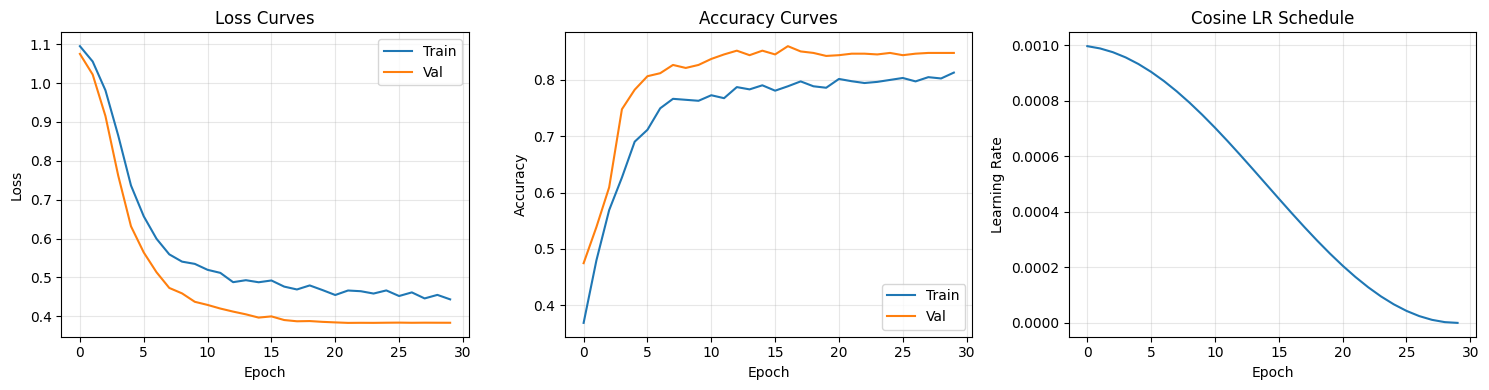

In [10]:
# ============================================================================
# STEP 9: VISUALIZE TRAINING CURVES
# ----------------------------------------------------------------------------
# Loss curves tell you nearly everything about training health:
#   - Both losses decreasing together: model is learning
#   - Train loss drops, val plateaus or rises: OVERFITTING — add regularization
#   - Neither decreases: UNDERFITTING — bigger model, lower LR, or longer training
#   - Losses oscillate wildly: learning rate too high
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

# LR schedule
axes[2].plot(history["lr"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Cosine LR Schedule")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()

In [11]:
# ============================================================================
# STEP 10: FINAL TEST SET EVALUATION
# ----------------------------------------------------------------------------
# Load the BEST model (from best validation epoch), not the final epoch model.
# Evaluate on test set ONCE — never iterate on test set, it would be data leakage.
# ============================================================================

# Load the best checkpoint
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)

# Final test evaluation
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\n=== FINAL TEST METRICS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")


=== FINAL TEST METRICS ===
Test Loss: 0.3818
Test Acc:  0.8560


In [12]:
# ============================================================================
# STEP 11: SAVING THE MODEL FOR SERVING
# ----------------------------------------------------------------------------
# Three approaches, each with tradeoffs:
#
# 1. state_dict (RECOMMENDED for research/internal use)
#    - Just the learned parameters as a dict
#    - Requires the model class definition to load
#    - Smallest, most flexible, version-control friendly
#
# 2. Entire model (torch.save(model, ...))
#    - Pickles the whole Python object
#    - Brittle: breaks if class definition changes
#    - Generally avoided
#
# 3. TorchScript (RECOMMENDED for production)
#    - Compiles model to a serializable IR (intermediate representation)
#    - Runnable WITHOUT the original Python class definition
#    - Can run in C++ environments (libtorch)
#    - Slight performance improvement from compilation
# ============================================================================

# ----- Approach 1: state_dict (already saved as best_model.pt) -----
# To load later in another script:
#   model = NeuralNetwork(input_dim=10, n_classes=3)   # rebuild architecture
#   model.load_state_dict(torch.load("best_model.pt"))
#   model.eval()

# ----- Approach 3: TorchScript (production-grade) -----
model.eval()  # MUST be in eval mode before scripting

# Two ways to script:
#   - torch.jit.script(): handles control flow, more flexible
#   - torch.jit.trace():  records one execution, faster but no dynamic control flow
# For an MLP, both work. We'll use script() because it's more robust.

scripted_model = torch.jit.script(model)
scripted_model.save("model_scripted.pt")

# Also save normalization stats — these are needed at inference time
# Wrap stats in a tensor and save separately or with the model
np.save("normalization_mean.npy", mean)
np.save("normalization_std.npy", std)

print("Saved files:")
print("  - best_model.pt          (state_dict for reloading)")
print("  - model_scripted.pt      (TorchScript for production serving)")
print("  - normalization_mean.npy (preprocessing stats)")
print("  - normalization_std.npy  (preprocessing stats)")

Saved files:
  - best_model.pt          (state_dict for reloading)
  - model_scripted.pt      (TorchScript for production serving)
  - normalization_mean.npy (preprocessing stats)
  - normalization_std.npy  (preprocessing stats)


In [13]:
# ============================================================================
# STEP 12: INFERENCE / SERVING — END-TO-END EXAMPLE
# ----------------------------------------------------------------------------
# This is what your inference server would do for each incoming request.
# Wrap in a class that loads everything once and exposes a predict() method.
# ============================================================================

class ModelServer:
    """Inference wrapper. Loads model + preprocessing once, exposes predict()."""
    
    def __init__(self, model_path, mean_path, std_path, device="cpu"):
        # Load TorchScript model — does NOT need the original NeuralNetwork class
        self.model = torch.jit.load(model_path, map_location=device)
        self.model.eval()  # paranoid: ensure eval mode
        
        # Load preprocessing stats
        self.mean = np.load(mean_path)  # shape: (10,)
        self.std  = np.load(std_path)   # shape: (10,)
        
        self.device = device
    
    @torch.no_grad()
    def predict(self, x_raw):
        """
        x_raw: numpy array of shape (n_samples, n_features) or (n_features,)
        Returns: predicted class indices and probabilities
        """
        # Handle single sample case
        if x_raw.ndim == 1:
            x_raw = x_raw[None, :]   # add batch dim: (n_features,) → (1, n_features)
        
        # Preprocess: apply same normalization as training
        x_normalized = (x_raw - self.mean) / self.std
        # shape: (n_samples, n_features)
        
        # Convert to tensor
        x_tensor = torch.from_numpy(x_normalized).float().to(self.device)
        # shape: (n_samples, n_features), requires_grad=False
        
        # Forward pass
        logits = self.model(x_tensor)
        # shape: (n_samples, n_classes)
        
        # Apply softmax to get probabilities
        # (Don't do this inside the model — keep model outputs as logits, 
        # convert at serving time for flexibility)
        probs = F.softmax(logits, dim=1)
        # shape: (n_samples, n_classes), each row sums to 1
        
        # Get predicted classes
        preds = probs.argmax(dim=1)
        # shape: (n_samples,)
        
        return preds.cpu().numpy(), probs.cpu().numpy()

# Test the server
server = ModelServer(
    model_path="model_scripted.pt",
    mean_path="normalization_mean.npy",
    std_path="normalization_std.npy",
    device=device
)

# Simulate a real prediction request: 5 random new samples
new_samples = np.random.randn(5, N_FEATURES).astype(np.float32)
preds, probs = server.predict(new_samples)

print(f"Predictions: {preds}")
# Output: e.g., [1 2 0 1 2]
print(f"Probabilities shape: {probs.shape}")
# Output: (5, 3)
print(f"Probabilities (rounded):")
print(np.round(probs, 3))
# Output: each row sums to 1

Predictions: [1 1 1 2 1]
Probabilities shape: (5, 3)
Probabilities (rounded):
[[0.203 0.71  0.087]
 [0.072 0.779 0.149]
 [0.1   0.651 0.249]
 [0.    0.001 0.999]
 [0.329 0.627 0.044]]


In [14]:
# ============================================================================
# STEP 13: VERIFICATION — TorchScript model matches original
# ----------------------------------------------------------------------------
# Always sanity-check that the serialized model gives identical outputs.
# Floating-point should be exactly identical for the same inputs.
# ============================================================================

# Get a test batch
for x, y in test_loader:
    x = x.to(device)
    
    # Original model
    model.eval()
    with torch.no_grad():
        out_original = model(x)
    
    # TorchScript model
    scripted = torch.jit.load("model_scripted.pt", map_location=device)
    scripted.eval()
    with torch.no_grad():
        out_scripted = scripted(x)
    
    # Compare
    max_diff = (out_original - out_scripted).abs().max().item()
    print(f"Max output difference: {max_diff:.10f}")
    # Should be 0.0 or near-zero (floating point precision)
    
    assert max_diff < 1e-6, "Models diverged!"
    print("✓ TorchScript model matches original")
    break

Max output difference: 0.0000000000
✓ TorchScript model matches original
